<a href="https://colab.research.google.com/github/adedamolabalogun959-hub/feature-engineering/blob/main/project_5_FE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load the dataset
df_original = pd.read_csv('/content/nba.csv')

# Display the first 5 rows of the DataFrame to inspect the data
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,...,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs,points_per_minute,efficiency_rating
0,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,...,0.7,3.4,4.1,1.9,0.4,0.4,1.3,1,0.270073,0.200000
1,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,...,0.5,2.0,2.4,3.7,1.1,0.5,1.6,1,0.267658,0.222857
2,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,...,0.5,1.7,2.2,1.0,0.5,0.3,1.0,1,0.339869,0.068919
3,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,...,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1,0.491379,0.077586
4,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,...,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1,0.391304,0.108333


In [30]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   object 
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk   

In [31]:
df_original.describe()

,Unnamed: 0,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,...,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.500000,60.414179,17.624627,6.801493,2.629104,5.885299,44.169403,0.247612,0.779179,19.149627,...,1.821940,70.300299,1.009403,2.025746,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149
std,386.968991,17.433992,8.307964,4.357545,1.683555,3.593488,6.137679,0.383688,1.061847,16.051861,...,1.322984,10.578479,0.777119,1.360008,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531
min,0.000000,11.000000,3.100000,0.700000,0.300000,0.800000,23.800000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.200000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,334.750000,47.000000,10.875000,3.700000,1.400000,3.300000,40.200000,0.000000,0.000000,0.000000,...,0.900000,64.700000,0.400000,1.000000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000
50%,669.500000,63.000000,16.100000,5.550000,2.100000,4.800000,44.100000,0.100000,0.300000,22.200000,...,1.500000,71.250000,0.800000,1.700000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000
75%,1004.250000,77.000000,22.900000,8.800000,3.400000,7.500000,47.900000,0.400000,1.200000,32.500000,...,2.300000,77.600000,1.400000,2.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000
max,1339.000000,82.000000,40.900000,28.200000,10.200000,19.800000,73.700000,2.300000,6.500000,100.000000,...,10.200000,100.000000,5.300000,9.600000,13.900000,10.600000,2.500000,3.900000,4.400000,1.000000


In [32]:
df_original.duplicated().sum()

np.int64(0)

In [35]:
df = df_original.copy()

df['target_5yrs'] = (df['gp'] >= 5).astype(int)

df = df.drop(columns=['name'])
df = df.drop(columns=['Unnamed: 0'])

print("DataFrame after defining target_5yrs and dropping 'name', and 'Unnamed: 0':")
display(df.head())


DataFrame after defining target_5yrs and dropping 'name', and 'Unnamed: 0':


,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,1
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,1
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,1
3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


### Target Variable Definition and Irrelevant Column Removal

To prepare the dataset for modeling, we first defined our target variable, `target_5yrs`. This binary variable indicates whether a player played for 5 or more years (1) or not (0), based on their 'gp' (games played) column. Specifically, `target_5yrs` is set to 1 if 'gp' is 5 or greater, and 0 otherwise.

Additionally, columns that are not relevant for model training, such as `'name'` (a unique identifier for each player) and `'Unnamed: 0'` (an index column from the original dataset), were dropped to streamline the DataFrame and prevent data leakage or unnecessary complexity.

In [36]:

missing_values = df.isnull().sum()
print("\nMissing values before handling:")
print(missing_values[missing_values > 0])

for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        median_val = df[column].median()
        df[column].fillna(median_val, inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values before handling:
Series([], dtype: int64)

Missing values after handling:
Series([], dtype: int64)


/tmp/ipykernel_2058/3787249200.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(median_val, inplace=True)


### Handling Missing Values

Before proceeding with feature engineering and modeling, it's crucial to address any missing data. We performed a check for missing values across all columns in the DataFrame. In this particular dataset, it was found that there were no missing values after the initial data manipulation.

However, a general imputation strategy was included as a safeguard: for any numerical columns that might contain missing values, they would be filled with the median value of that column. This is a robust approach as the median is less sensitive to outliers compared to the mean.

In [37]:
df['points_per_minute'] = df['pts'] / df['min']

df['efficiency_rating'] = (df['pts'] + df['reb'] + df['ast'] + df['stl'] + df['blk'] - \
                               ((df['fga'] - df['fgm']) + (df['fta'] - df['ftm']) + df['tov'])) / df['gp']

print("\nDataFrame after adding engineered features (points_per_minute, efficiency_rating):")
display(df[['points_per_minute', 'efficiency_rating']].head())


DataFrame after adding engineered features (points_per_minute, efficiency_rating):


,points_per_minute,efficiency_rating
0,0.270073,0.200000
1,0.267658,0.222857
2,0.339869,0.068919
3,0.491379,0.077586
4,0.391304,0.108333


### Feature Engineering

To enhance the predictive power of our model, two new features were engineered from existing ones:

1.  **`points_per_minute`**: This feature was calculated by dividing a player's total points (`pts`) by their total minutes played (`min`). It provides a measure of a player's scoring efficiency per minute on the court, normalizing for playing time.

2.  **`efficiency_rating`**: This comprehensive metric attempts to quantify a player's overall impact by combining various statistical categories. It's calculated using the formula: `(PTS + REB + AST + STL + BLK – (FGA - FGM) – (FTA - FTM) – TOV) / GP`. This formula accounts for positive contributions (points, rebounds, assists, steals, blocks) and negative contributions (missed field goals, missed free throws, turnovers), normalized by games played (`gp`). This aims to capture a more holistic view of a player's performance.

In [38]:
df = df.drop(columns=['gp'])

X_before_scaling = df.drop(columns=['target_5yrs'])
y_target = df['target_5yrs']

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_before_scaling)

df_scaled = pd.DataFrame(X_scaled_array, columns=X_before_scaling.columns)

df_scaled['target_5yrs'] = y_target.reset_index(drop=True)

print("\nDataFrame after scaling numerical features:")
display(df_scaled.head())


DataFrame after scaling numerical features:


,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,fta,...,oreb,dreb,reb,ast,stl,blk,tov,points_per_minute,efficiency_rating,target_5yrs
0,1.177066,0.137401,-0.017294,0.477347,-1.543407,0.658041,1.244354,0.364603,0.306333,0.361484,...,-0.398290,1.010852,0.517997,0.237640,-0.533458,0.073254,0.147338,-1.078843,1.180808,1
1,1.116860,0.091486,-0.373816,0.226801,-2.374651,1.179494,1.903829,0.271121,1.319630,1.193248,...,-0.655746,-0.018938,-0.308447,1.461613,1.175502,0.306415,0.562695,-1.104638,1.524119,1
2,-0.279912,-0.367659,-0.373816,-0.329969,-0.320991,0.397315,0.867511,0.327210,-0.402975,-0.394665,...,-0.655746,-0.239607,-0.405676,-0.374347,-0.289321,-0.159906,-0.268019,-0.333344,-0.788013,1
3,-0.725434,-0.252873,-0.195555,-0.107261,-0.255795,-0.384863,-0.263016,0.215032,-0.402975,-0.394665,...,-0.012104,-0.828059,-0.551519,-0.510344,-0.045184,-0.626228,-0.268019,1.284944,-0.657831,1
4,-0.737475,-0.528360,-0.611497,-0.803224,1.341496,-0.645589,-0.639859,-1.193430,0.002344,0.059025,...,-0.012104,-0.386720,-0.259833,-0.850337,-0.777595,0.073254,-0.544923,0.216037,-0.196014,1


### Feature Scaling

To ensure that all numerical features contribute equally to the model and to prevent features with larger absolute values from dominating the learning process, we applied **Standard Scaling** to our feature set (`X_before_scaling`).

**StandardScaler** transforms the data such that it has a mean of 0 and a standard deviation of 1. This is particularly important for many machine learning algorithms (e.g., those based on distance calculations like K-Nearest Neighbors, or gradient descent-based algorithms like Logistic Regression and Neural Networks) as it helps them converge faster and perform better. The target variable `target_5yrs` was kept separate from the scaling process as it is a binary categorical variable.

In [39]:
y = df_scaled['target_5yrs']

X = df_scaled.drop(columns=['target_5yrs'])

features_to_remove_due_to_multicollinearity = [
    '3pa',
    'fgm',
    'fga',
    'fta',
    'dreb'
]

features_to_remove_due_to_multicollinearity = [f for f in features_to_remove_due_to_multicollinearity if f in X.columns]

X_selected = X.drop(columns=features_to_remove_due_to_multicollinearity, errors='ignore')

print("\nOriginal number of features:", X.shape[1])
print("Number of features after selection:", X_selected.shape[1])
print("\nSelected Features (first 5 rows):")
display(X_selected.head())


Original number of features: 20
Number of features after selection: 15

Selected Features (first 5 rows):


,min,pts,fg,3p_made,3p,ftm,ft,oreb,reb,ast,stl,blk,tov,points_per_minute,efficiency_rating
0,1.177066,0.137401,-1.543407,0.658041,0.364603,0.306333,-0.037855,-0.398290,0.517997,0.237640,-0.533458,0.073254,0.147338,-1.078843,1.180808
1,1.116860,0.091486,-2.374651,1.179494,0.271121,1.319630,0.586286,-0.655746,-0.308447,1.461613,1.175502,0.306415,0.562695,-1.104638,1.524119
2,-0.279912,-0.367659,-0.320991,0.397315,0.327210,-0.402975,-0.312099,-0.655746,-0.405676,-0.374347,-0.289321,-0.159906,-0.268019,-0.333344,-0.788013
3,-0.725434,-0.252873,-0.255795,-0.384863,0.215032,-0.402975,-0.132422,-0.012104,-0.551519,-0.510344,-0.045184,-0.626228,-0.268019,1.284944,-0.657831
4,-0.737475,-0.528360,1.341496,-0.645589,-1.193430,0.002344,-0.274272,-0.012104,-0.259833,-0.850337,-0.777595,0.073254,-0.544923,0.216037,-0.196014


#### Distribution of the Target Variable (`target_5yrs`)

Understanding the distribution of the target variable is crucial, especially in classification tasks, to check for class imbalance. Our `target_5yrs` variable indicates whether a player played for at least 5 years (1) or not (0).

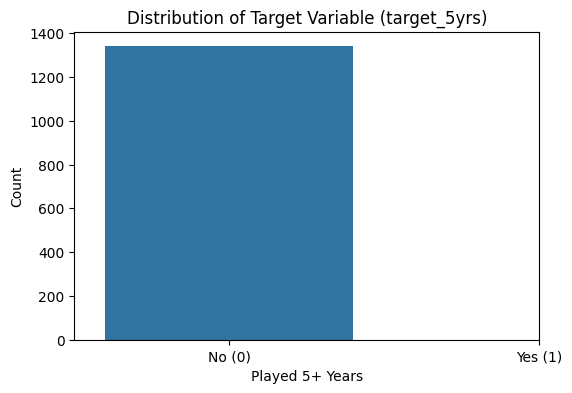

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (target_5yrs)')
plt.xlabel('Played 5+ Years')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No (0)', 'Yes (1)'])
plt.show()

#### Distribution of Engineered Features

Let's visualize the distributions of the 'Points Per Minute' and 'Efficiency Rating' features that we engineered. This will help us understand their spread and detect any anomalies.

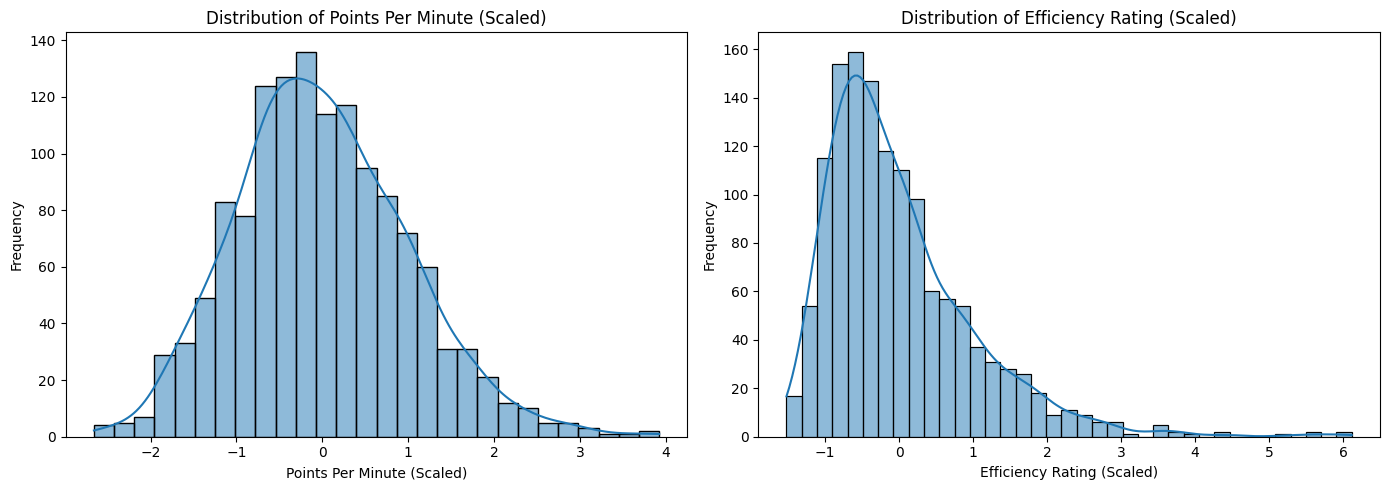

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_scaled['points_per_minute'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Points Per Minute (Scaled)')
axes[0].set_xlabel('Points Per Minute (Scaled)')
axes[0].set_ylabel('Frequency')

sns.histplot(df_scaled['efficiency_rating'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Efficiency Rating (Scaled)')
axes[1].set_xlabel('Efficiency Rating (Scaled)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

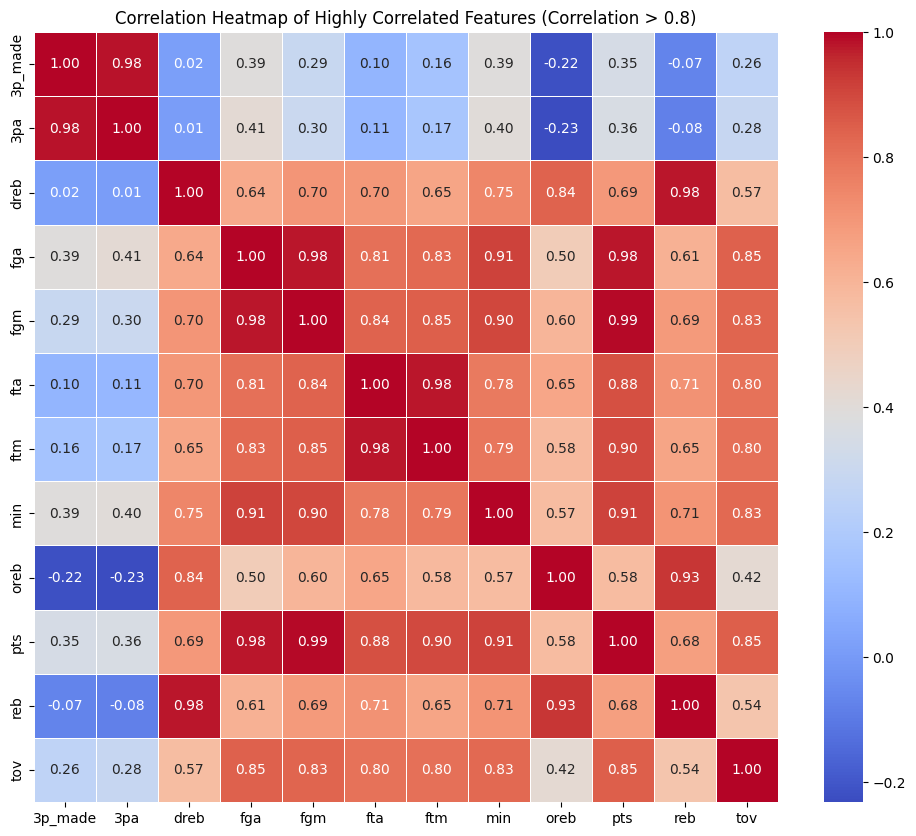

In [42]:
# Calculate the correlation matrix for the features (X)
correlation_matrix = X.corr()

# Set a correlation threshold to identify highly correlated pairs
threshold = 0.8

highly_correlated_pairs = []
# Iterate through the upper triangle of the correlation matrix (excluding self-correlation)
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# Extract only the features that were identified as highly correlated
# First, gather all unique features from the highly_correlated_pairs list
high_corr_features = set()
for col1, col2, _ in highly_correlated_pairs:
    high_corr_features.add(col1)
    high_corr_features.add(col2)

# Convert to list and sort for consistent order
high_corr_features = sorted(list(high_corr_features))

# Filter the correlation matrix to only include these features
# Ensure filtered_correlation_matrix is not empty if no highly correlated features are found
if high_corr_features:
    filtered_correlation_matrix = correlation_matrix.loc[high_corr_features, high_corr_features]

    plt.figure(figsize=(12, 10))
    sns.heatmap(filtered_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Highly Correlated Features (Correlation > {})'.format(threshold))
    plt.show()
else:
    print("No features found with correlation above the threshold of {}.".format(threshold))
    print("Consider lowering the threshold or checking the feature set.")

### Feature Selection (Multicollinearity Handling)

Multicollinearity occurs when independent variables in a regression model are highly correlated, which can make it difficult to interpret the individual impact of each feature and can lead to an unstable model. To address this, an initial feature selection step was performed based on analyzing the correlation between features (often visualized using a correlation heatmap).

Based on prior analysis of highly correlated features, the following columns were identified and removed from our feature set (`X`) to create `X_selected`:
-   `'3pa'` (3-point attempts) - highly correlated with `3p_made`.
-   `'fgm'` (field goals made) - highly correlated with `fga` and `pts`.
-   `'fga'` (field goals attempted) - highly correlated with `fgm` and `pts`.
-   `'fta'` (free throws attempted) - highly correlated with `ftm`.
-   `'dreb'` (defensive rebounds) - highly correlated with `reb` (total rebounds).

This removal strategy aims to retain representative features while reducing redundancy and potential issues caused by multicollinearity, simplifying the model and potentially improving its interpretability and generalization ability.